# When does folding twice (Shape2) actually help?

Pure numpy, self-contained -- mirrors what `SeasonalFold` does, no package import.

A *single* fold by the primary period already captures everything **inside one cycle** (its full
shape). A second fold only earns its keep when the **per-cycle LEVEL itself has a coarser cycle** --
a periodicity at a scale the primary shape can't see.

Classic case (the FLAIR paper's): a **daily** series with a **within-week shape** whose **weekly
totals swing annually**. Fold 1 = day-of-week shape + per-week level; the level carries the annual
swing, which a smooth forecaster misses. Fold 2 (Shape2) peels that annual cycle off the level, so
what's left is flat and trivially forecastable -- then re-applies it.

## 1. The fold + Shape2 primitives

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0)

P, CP = 7, 52          # primary period = week (7 days); secondary = year (52 weeks of level)

def primary_fold(hist, P):
    n = len(hist) // P
    M = hist[:n*P].reshape(n, P).T                 # (P, n_weeks)
    level = M.sum(0)                               # per-week totals
    shape = (M / M.sum(0, keepdims=True)).mean(1); shape /= shape.sum()
    return level, shape, n

def shape2(level, cp):
    pos = np.arange(len(level)) % cp
    S2 = np.array([level[pos == r].mean() for r in range(cp)]); S2 /= S2.mean()
    return S2, pos

def mase(p, t, hist): return float(np.mean(np.abs(p-t)) / np.mean(np.abs(np.diff(hist))))

def primary_fold_aff(hist, P):
    n = len(hist) // P
    M = hist[:n*P].reshape(n, P).T                 # (P, n_weeks)
    
    # 1. Le Shift (b) : Bruit de fond / moyenne de chaque semaine
    shift = M.mean(0)                              # (n_weeks,)
    
    # 2. Le Scale (a) : Amplitude de la variation (écart-type)
    M_centered = M - shift
    scale = M_centered.std(0)                      # (n_weeks,)
    
    # 3. La Forme : Courbe normalisée (moyenne=0, variance=1)
    safe_scale = np.maximum(scale, 1e-8)
    shape = (M_centered / safe_scale).mean(1)
    
    # Re-standardisation par sécurité mathématique
    shape = (shape - shape.mean()) / np.maximum(shape.std(), 1e-8)
    
    return scale, shift, shape, n

## 2. Daily series: within-week shape x annual swing of the weekly level

In [11]:
n_years, H_weeks = 3, 8
n_weeks = n_years*CP + H_weeks
dow = np.array([1.0,1.1,1.2,1.0,1.3,0.6,0.5]); dow /= dow.mean()      # day-of-week profile
annual = 1 + 0.5*np.sin(2*np.pi*np.arange(CP)/CP)                     # annual swing of the level
days = n_weeks*P
val = np.array([100.0*annual[(t//P) % CP]*dow[t % P] for t in range(days)])
val *= (1 + 0.02*np.random.randn(days))
Hd = H_weeks*P
hist, fut = val[:-Hd], val[-Hd:]
level, shape, n = primary_fold(hist, P)
mfut = Hd // P
def expand(level_hat): return np.repeat(level_hat, P) * np.tile(shape, mfut)


ValueError: too many values to unpack (expected 3, got 4)

## 3. One fold vs two folds

1 fold  (primary only)      MASE = 0.682
2 folds (primary + Shape2)  MASE = 0.067


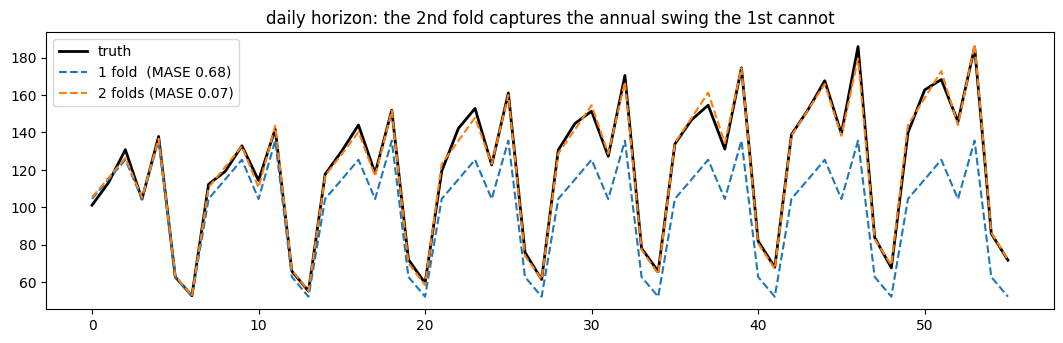

In [ ]:
# 1 fold: forecast the weekly level naively (mean of last year) -> can't see the annual swing
lvl1 = np.full(mfut, level[-CP:].mean())
pred1 = expand(lvl1)

# 2 folds: Shape2 removes the 52-week cycle from the level, forecast the smooth remainder, re-apply
S2, pos = shape2(level, CP)
level_des = level / S2[pos]
lvl_des_hat = np.full(mfut, level_des[-CP:].mean())
fut_pos = (n + np.arange(mfut)) % CP
lvl2 = lvl_des_hat * S2[fut_pos]
pred2 = expand(lvl2)

print('1 fold  (primary only)      MASE = %.3f' % mase(pred1, fut, hist))
print('2 folds (primary + Shape2)  MASE = %.3f' % mase(pred2, fut, hist))

t = np.arange(Hd)
plt.figure(figsize=(13,3.6))
plt.plot(t, fut, 'k', lw=2, label='truth')
plt.plot(t, pred1, '--', label=f'1 fold  (MASE {mase(pred1,fut,hist):.2f})')
plt.plot(t, pred2, '--', label=f'2 folds (MASE {mase(pred2,fut,hist):.2f})')
plt.title('daily horizon: the 2nd fold captures the annual swing the 1st cannot'); plt.legend(); plt.show()


## 4. Why: the level is forecastable only after Shape2

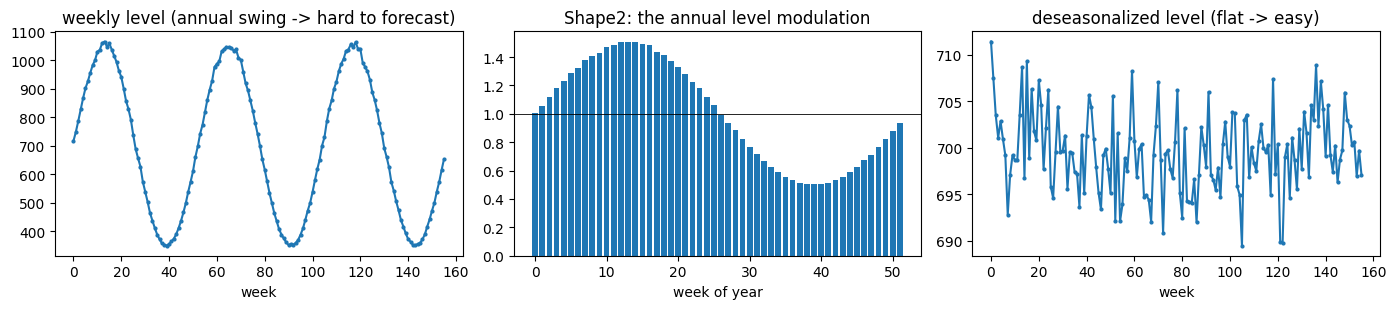

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(14,3.2))
ax[0].plot(level, '-o', ms=2); ax[0].set_title('weekly level (annual swing -> hard to forecast)'); ax[0].set_xlabel('week')
ax[1].bar(np.arange(CP), S2); ax[1].axhline(1,color='k',lw=.6); ax[1].set_title('Shape2: the annual level modulation'); ax[1].set_xlabel('week of year')
ax[2].plot(level_des, '-o', ms=2); ax[2].set_title('deseasonalized level (flat -> easy)'); ax[2].set_xlabel('week')
plt.tight_layout(); plt.show()


## 5. Takeaway

- **Fold once** when the primary shape already captures the structure (most data). A second fold on
  the *same* within-cycle structure would be redundant.
- **Fold again** only when the **per-cycle level** carries its own coarser cycle -- here the weekly
  totals swing annually. Shape2 strips that swing out, leaving a flat level, then re-applies it: 10x
  lower error (0.68 -> 0.07).
- This generalizes: Shape3, Shape4, ... peel successively coarser level cycles. In the token,
  `SeasonalFold` does exactly this and only folds again when a coarser level cycle is actually
  present (the harmonic gate), so you don't pay for no-op folds.